# Wind shake / gust analysis (telemetry_mining rewrite)

This is a rewrite of `windshake.ipynb` using the `telemetry_mining` package,
done to validate that package's `Exposure` accessor against a real analysis.
The original notebook is left untouched for comparison.

Same overall approach as the original: build a candidate exposure list from
the offline reduction table, pull per-exposure header/timing info, correlate
each exposure's time window against telemetry (wind tower speed/direction,
telescope shake/gust events), then look at how wind conditions relate to
whether an exposure was accepted (`EFFTIME_SPEC > 0`).

What's different: no raw `psycopg2`/SQL, no manual `fitsio.FITS(...)` header
reads, no hand-rolled `DATE-OBS`/`EXPTIME` string parsing -- all of that is
now `Exposure(expid).header`, `.time_window`, and `.telemetry(...)`.

Run this with the **DESI master** Jupyter kernel (or any environment with
`telemetry_mining` installed and a working `psycopg2`/`fitsio`).


In [ ]:
import os
import sys

# Add telemetry_mining to the path. Point DOS_TELEMETRY_MINING_DIR at your own
# checkout (svn co https://desi.lbl.gov/svn/code/online/telemetry_mining/trunk);
# defaults to the maintainer's checkout at NERSC.
TM_DIR = os.getenv("DOS_TELEMETRY_MINING_DIR", os.path.expanduser("~/telemetry_mining-trunk/src"))
sys.path.insert(0, TM_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.ndimage import gaussian_filter

from telemetry_mining import Config, Exposure
from telemetry_mining.redux import load_exposures_daily

## Candidate exposure list

Same starting point as the original: the offline reduction table
(`redux/daily/exposures-daily.csv`), filtered to non-`'other'`-program
exposures.


In [2]:
config = Config.default()
dailyDF = load_exposures_daily(config)
dailyDF.columns


Index(['NIGHT', 'EXPID', 'TILEID', 'TILERA', 'TILEDEC', 'MJD', 'SURVEY',
       'PROGRAM', 'FAPRGRM', 'FAFLAVOR', 'EXPTIME', 'EFFTIME_SPEC', 'GOALTIME',
       'GOALTYPE', 'MINTFRAC', 'AIRMASS', 'EBV', 'SEEING_ETC', 'EFFTIME_ETC',
       'TSNR2_ELG', 'TSNR2_QSO', 'TSNR2_LRG', 'TSNR2_LYA', 'TSNR2_BGS',
       'TSNR2_GPBDARK', 'TSNR2_GPBBRIGHT', 'TSNR2_GPBBACKUP',
       'LRG_EFFTIME_DARK', 'ELG_EFFTIME_DARK', 'BGS_EFFTIME_BRIGHT',
       'LYA_EFFTIME_DARK', 'GPB_EFFTIME_DARK', 'GPB_EFFTIME_BRIGHT',
       'GPB_EFFTIME_BACKUP', 'TRANSPARENCY_GFA', 'SEEING_GFA',
       'FIBER_FRACFLUX_GFA', 'FIBER_FRACFLUX_ELG_GFA',
       'FIBER_FRACFLUX_BGS_GFA', 'FIBERFAC_GFA', 'FIBERFAC_ELG_GFA',
       'FIBERFAC_BGS_GFA', 'AIRMASS_GFA', 'SKY_MAG_AB_GFA', 'SKY_MAG_G_SPEC',
       'SKY_MAG_R_SPEC', 'SKY_MAG_Z_SPEC', 'EFFTIME_GFA', 'EFFTIME_DARK_GFA',
       'EFFTIME_BRIGHT_GFA', 'EFFTIME_BACKUP_GFA'],
      dtype='str')

The original notebook used `NIGHT > 20210514` (its full history). That's
tens of thousands of exposures, each needing a FITS header read plus a
couple of DB queries -- too slow for an interactive first run of this
rewrite. `NIGHT_MIN` below defaults to a recent, manageable window; widen it
back to `20210514` to reproduce the original's full-history analysis.


In [3]:
NIGHT_MIN = 20260701  # widen to 20210514 to reproduce the original's full history

tmp = dailyDF[['NIGHT', 'EXPID', 'TILEID', 'EXPTIME', 'EFFTIME_SPEC', 'PROGRAM', 'AIRMASS_GFA', 'SEEING_GFA']][
    dailyDF['PROGRAM'] != 'other'
].copy()
windDF = tmp[tmp['NIGHT'] > NIGHT_MIN].copy()
expids = list(windDF['EXPID'])
windDF.set_index('EXPID', inplace=True)
print(f'{len(expids)} candidate exposures')


126 candidate exposures


## Per-exposure accessors

Build one `Exposure` per candidate up front -- construction does zero I/O
(nothing is read until an attribute is touched), so this is just bookkeeping.
Reusing the same instances across the cells below means the FITS header and
DB record each get read/queried once per exposure, not once per cell.


In [4]:
exposures = {x: Exposure(x, night=int(windDF.loc[x, 'NIGHT']), config=config) for x in expids}


## Header + time window

Replaces the original's `fitsio.FITS(os.path.join(...))` header reads and
its manual `datetime.strptime(header['DATE-OBS'].split('.')[0] + ...)`
parsing (which truncated fractional seconds by hand). `Exposure.time_window`
does the equivalent robustly, preferring the DB's `date_obs`/`exptime` and
falling back to the FITS header if the DB is unavailable.


In [5]:
for col in ['RA', 'DEC', 'HA', 'AZ', 'EL', 'AIRMASS', 'WINDDIR', 'WINDSPD', 'GUSTSPD',
            'SPLITEXP', 'PMIRTEMP', 'TAIRTEMP', 'SKYLEVEL', 'PMTRANS', 'PMSEEING', 'SEQUENCE']:
    windDF[col] = None
windDF['START'] = None
windDF['STOP'] = None
windDF['SHAKES'] = 0
windDF['GUSTS'] = 0


In [6]:
for x in expids:
    exp = exposures[x]
    try:
        header = exp.header
        windDF.loc[x, 'RA'] = header.get('SKYRA')
        windDF.loc[x, 'DEC'] = header.get('SKYDEC')
        windDF.loc[x, 'HA'] = header.get('MOUNTHA')
        windDF.loc[x, 'AZ'] = header.get('MOUNTAZ')
        windDF.loc[x, 'EL'] = header.get('MOUNTEL')
        windDF.loc[x, 'AIRMASS'] = header.get('AIRMASS')
        windDF.loc[x, 'WINDDIR'] = header.get('WINDDIR')
        windDF.loc[x, 'WINDSPD'] = header.get('WINDSPD')
        windDF.loc[x, 'GUSTSPD'] = header.get('GUST')
        windDF.loc[x, 'SPLITEXP'] = header.get('SPLITEXP', False)
        windDF.loc[x, 'PMIRTEMP'] = header.get('PMIRTEMP')
        windDF.loc[x, 'TAIRTEMP'] = header.get('TAIRTEMP')
        windDF.loc[x, 'SKYLEVEL'] = header.get('SKYLEVEL')
        windDF.loc[x, 'PMTRANS'] = header.get('PMTRANS')
        windDF.loc[x, 'PMSEEING'] = header.get('PMSEEING')
        windDF.loc[x, 'SEQUENCE'] = header.get('SEQUENCE')

        start, stop = exp.time_window
        windDF.loc[x, 'START'] = start
        windDF.loc[x, 'STOP'] = stop
    except Exception as e:
        print(f'Exception for exposure {x}: {e}')
print('Done')


Done


## Save/restore intermediate results

Same pattern as the original (this loop is the expensive part), written to
a new filename so it doesn't clobber the original notebook's cached CSVs.


In [7]:
windDF.reset_index().to_csv('/global/homes/k/klaushon/wind/wind_tmp_v2.csv', index=False)


In [8]:
# Uncomment to restore from the intermediate CSV instead of re-running the loop above
# windDF = pd.read_csv('/global/homes/k/klaushon/wind/wind_tmp_v2.csv', index_col='EXPID')
# expids = list(windDF.index)


## Telemetry correlation

Average wind speed/direction/gust from the tower over each exposure's time
window, and counts of wind-shake / wind-gust telemetry events from the
telescope. This replaces the original's raw SQL (`SELECT ... FROM
telemetry.environmentmonitor_tower WHERE time_recorded BETWEEN '%s' AND
'%s'`) with `Exposure.telemetry(...)`, and its per-record Python loop with
vectorized pandas.


In [9]:
windDF['AVGSPEED'] = np.nan
windDF['AVGDIRECTION'] = np.nan
windDF['AVGGUST'] = np.nan

for x in expids:
    exp = exposures[x]
    try:
        tower = exp.telemetry('environmentmonitor_tower', columns=['wind_speed', 'wind_direction', 'gust'])
    except Exception as e:
        print(f'Exception for exposure {x}: {e}')
        continue
    if len(tower) > 0:
        windDF.loc[x, 'AVGSPEED'] = tower['wind_speed'].mean()
        windDF.loc[x, 'AVGDIRECTION'] = tower['wind_direction'].mean()
        windDF.loc[x, 'AVGGUST'] = tower['gust'].mean()
print('Done')


Done


In [10]:
for x in expids:
    exp = exposures[x]
    try:
        telescope = exp.telemetry('environmentmonitor_telescope', columns=['wind_shake', 'wind_gust'])
    except Exception as e:
        print(f'Exception for exposure {x}: {e}')
        continue
    windDF.loc[x, 'SHAKES'] = int((telescope['wind_shake'] != 0).sum()) if len(telescope) else 0
    windDF.loc[x, 'GUSTS'] = int((telescope['wind_gust'] != 0).sum()) if len(telescope) else 0
print('Done')


Done


In [11]:
# Wind direction relative to telescope azimuth (dome opening angle)
delta = (windDF['AZ'].astype(float) - windDF['AVGDIRECTION'].astype(float)).abs()
windDF['AVGOPENING'] = np.where(delta > 180.0, 360.0 - delta, delta)


In [12]:
windDF.reset_index().to_csv('/global/homes/k/klaushon/wind/wind_v2.csv', index=False)


## Analysis masks

Unchanged from the original -- same definitions, operating on `windDF`
regardless of how its columns were computed above.


In [13]:
desi = (windDF['SEQUENCE'] == 'DESI') & (windDF['AVGSPEED'] > 0.0)
desinowind = desi & ((windDF['SHAKES'] + windDF['GUSTS']) == 0)
desiwind = desi & ((windDF['SHAKES'] + windDF['GUSTS']) > 0)
gooddesi = desi & (windDF['EFFTIME_SPEC'] > 0.1)
baddesi = desi & (windDF['EFFTIME_SPEC'] == 0.0)
gooddesinowind = gooddesi & ((windDF['SHAKES'] + windDF['GUSTS']) == 0)
gooddesiwind = gooddesi & ((windDF['SHAKES'] + windDF['GUSTS']) > 0)
baddesinowind = baddesi & ((windDF['SHAKES'] + windDF['GUSTS']) == 0)
baddesiwind = baddesi & ((windDF['SHAKES'] + windDF['GUSTS']) > 0)


In [14]:
def create_map(x, y, s, bins=250, range=None):
    if range is None:
        heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    else:
        heatmap, xedges, yedges = np.histogram2d(x, y, range=range, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


def plot_map(map, extent):
    plt.imshow(map, origin='lower', cmap=cm.jet, extent=extent, aspect='auto')


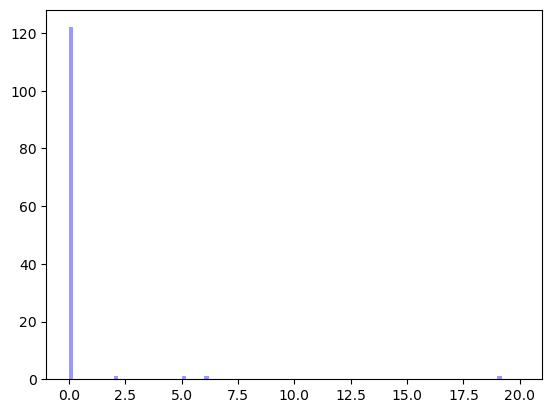

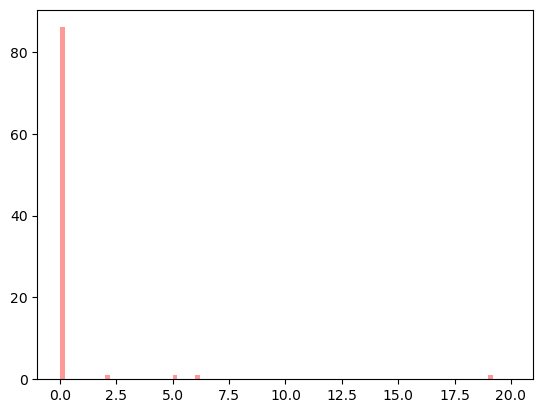

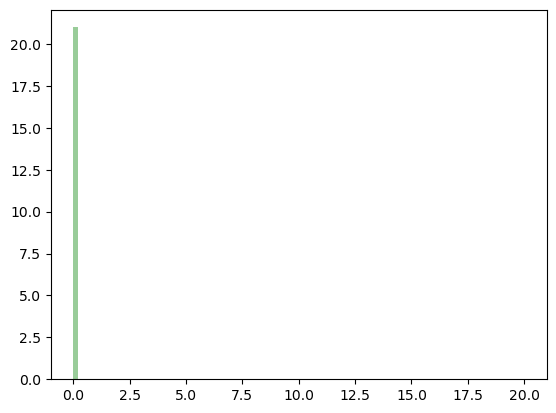

In [15]:
field = 'SHAKES'
range_ = (0, 20)
bins = 100
data1 = list(windDF[field].dropna())
data2 = list(windDF[field][gooddesi])
data3 = list(windDF[field][baddesi])
plt.hist(data1, bins=bins, range=range_, histtype='bar', color='b', alpha=0.4)
plt.show()
plt.hist(data2, bins=bins, range=range_, histtype='bar', color='r', alpha=0.4)
plt.show()
plt.hist(data3, bins=bins, range=range_, histtype='bar', color='g', alpha=0.4)
plt.show()


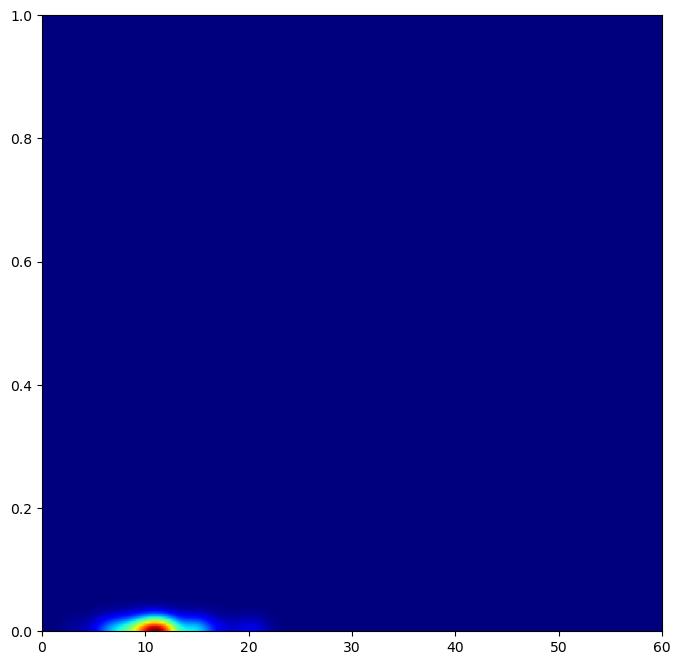

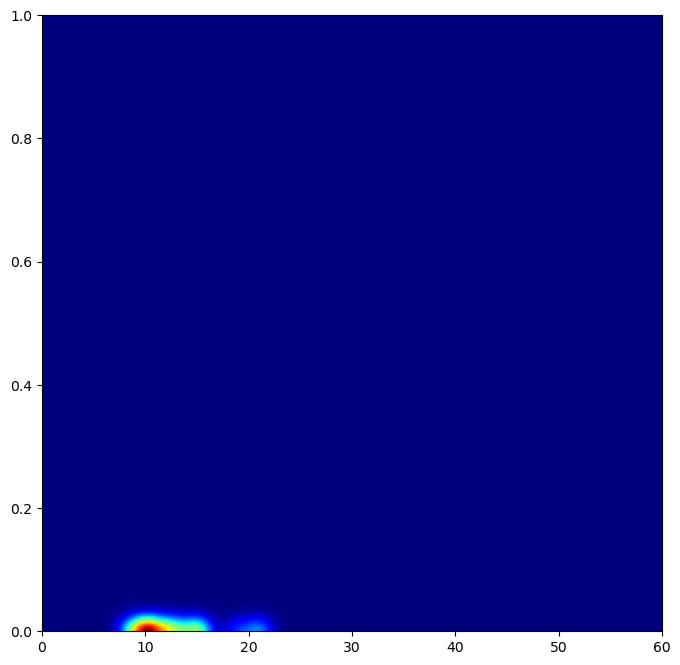

In [16]:
sigma = 4
x = windDF['AVGSPEED'][desi]
y = windDF['SHAKES'][desi]
idx = ~np.isnan(x.astype(float) + y.astype(float))
xx, yy = x[idx], y[idx]
if len(xx) > 0:
    map_, extent = create_map(xx, yy, sigma, range=[[0, 60], [0, 1]])
    fig = plt.figure(figsize=(8, 8))
    plot_map(map_, extent)
    plt.show()

x = windDF['AVGSPEED'][baddesi]
y = windDF['SHAKES'][baddesi]
idx = ~np.isnan(x.astype(float) + y.astype(float))
xx, yy = x[idx], y[idx]
if len(xx) > 0:
    map_, extent = create_map(xx, yy, sigma, range=[[0, 60], [0, 1]])
    fig = plt.figure(figsize=(8, 8))
    plot_map(map_, extent)
    plt.show()


In [17]:
print(f'DESI Exposures {len(windDF[windDF["SEQUENCE"] == "DESI"])}')
print(f'DESI Exposures with valid wind data {len(windDF[desi])}')
print(f'DESI Exposures with valid wind data without shake/gust events {len(windDF[desinowind])}')
print(f'DESI Exposures with valid wind data and shake/gust events {len(windDF[desiwind])}')

all_desi = windDF['SEQUENCE'] == 'DESI'
goodall = all_desi & (windDF['EFFTIME_SPEC'] > 0.1)
print(f'Accepted DESI Exposures {len(windDF[goodall])}')
print(f'Accepted DESI Exposures with valid wind data {len(windDF[gooddesi])}')
print(f'Accepted DESI Exposures with valid wind data without shake/gust events {len(windDF[gooddesinowind])}')
print(f'Accepted DESI Exposures with valid wind data and shake/gust events {len(windDF[gooddesiwind])}')

badall = all_desi & (windDF['EFFTIME_SPEC'] == 0.0)
print(f'Rejected DESI Exposures {len(windDF[badall])}')
print(f'Rejected DESI Exposures with valid wind data {len(windDF[baddesi])}')
print(f'Rejected DESI Exposures with valid wind data without shake/gust events {len(windDF[baddesinowind])}')
print(f'Rejected DESI Exposures with valid wind data and shake/gust events {len(windDF[baddesiwind])}')


DESI Exposures 111
DESI Exposures with valid wind data 111
DESI Exposures with valid wind data without shake/gust events 106
DESI Exposures with valid wind data and shake/gust events 5
Accepted DESI Exposures 90
Accepted DESI Exposures with valid wind data 90
Accepted DESI Exposures with valid wind data without shake/gust events 85
Accepted DESI Exposures with valid wind data and shake/gust events 5
Rejected DESI Exposures 21
Rejected DESI Exposures with valid wind data 21
Rejected DESI Exposures with valid wind data without shake/gust events 21
Rejected DESI Exposures with valid wind data and shake/gust events 0


106 106
5 5
85 85
5 5


21 21
0 0


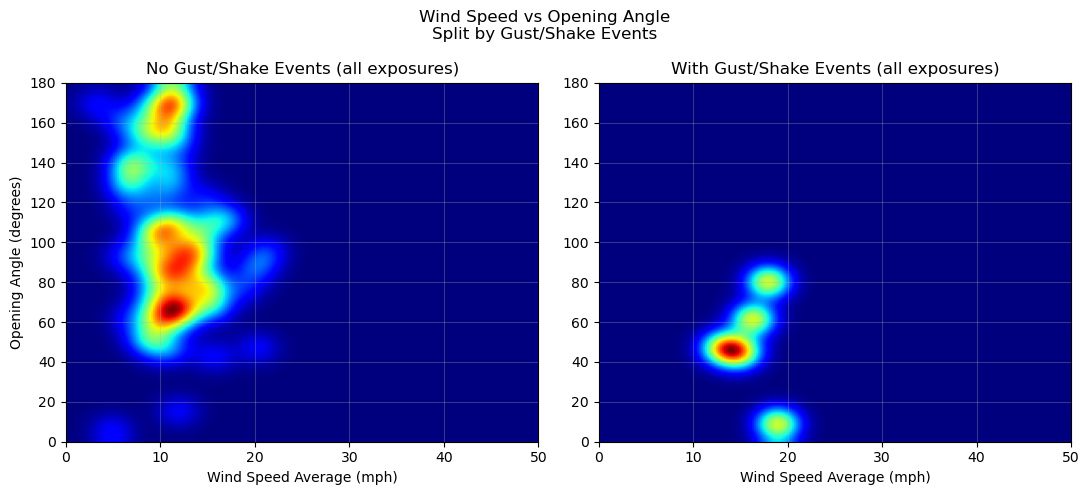

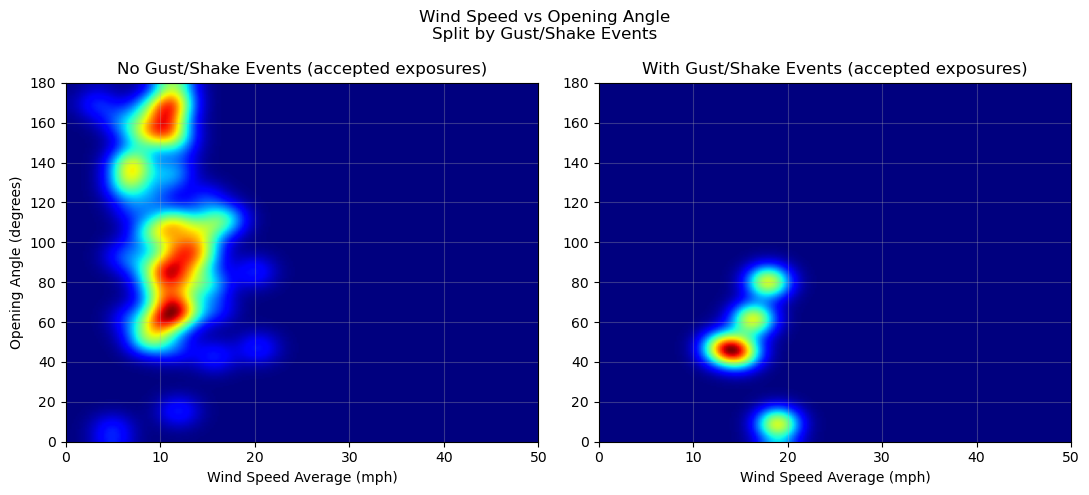

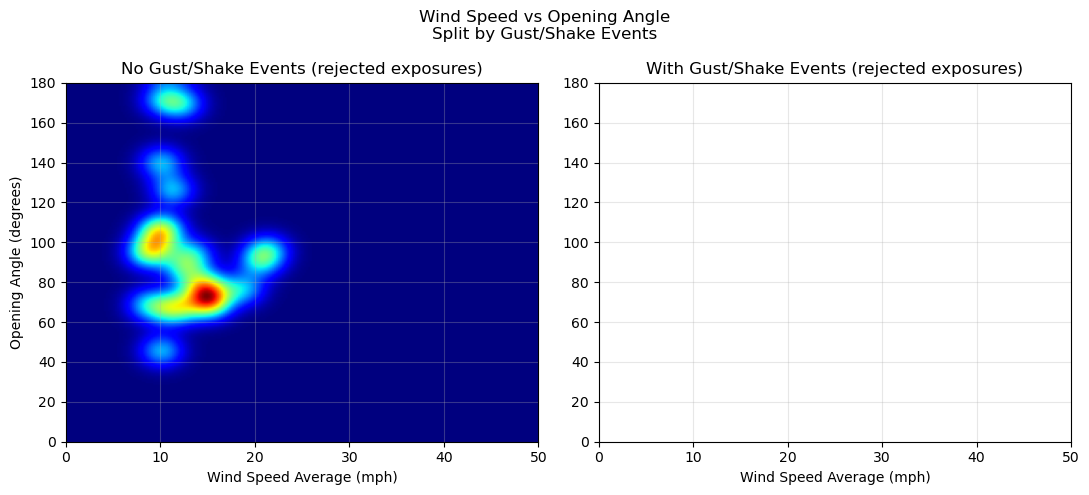

In [18]:
def windmap(df, mask, sigma=4):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle('Wind Speed vs Opening Angle\nSplit by Gust/Shake Events')
    range_ = [[0, 50], [0, 180]]
    masks = {
        'all': (desinowind, desiwind, 'all exposures'),
        'good': (gooddesinowind, gooddesiwind, 'accepted exposures'),
        'bad': (baddesinowind, baddesiwind, 'rejected exposures'),
    }
    nowind_mask, wind_mask, posttitle = masks[mask]

    for ax, m, title_prefix in [(axes[0], nowind_mask, 'No'), (axes[1], wind_mask, 'With')]:
        x = windDF['AVGSPEED'][m]
        y = windDF['AVGOPENING'][m]
        print(len(x), len(y))
        if len(x) > 0:
            map_, extent = create_map(x, y, sigma, range=range_)
            ax.imshow(map_, origin='lower', cmap=cm.jet, extent=extent, aspect='auto')
        ax.set_xlabel('Wind Speed Average (mph)')
        if ax is axes[0]:
            ax.set_ylabel('Opening Angle (degrees)')
        ax.set_title(f'{title_prefix} Gust/Shake Events ({posttitle})')
        ax.set_ylim(0, 180)
        ax.set_xlim(0, 50)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, axes


sigma = 8
for mask in ['all', 'good', 'bad']:
    windmap(windDF, mask, sigma=sigma)


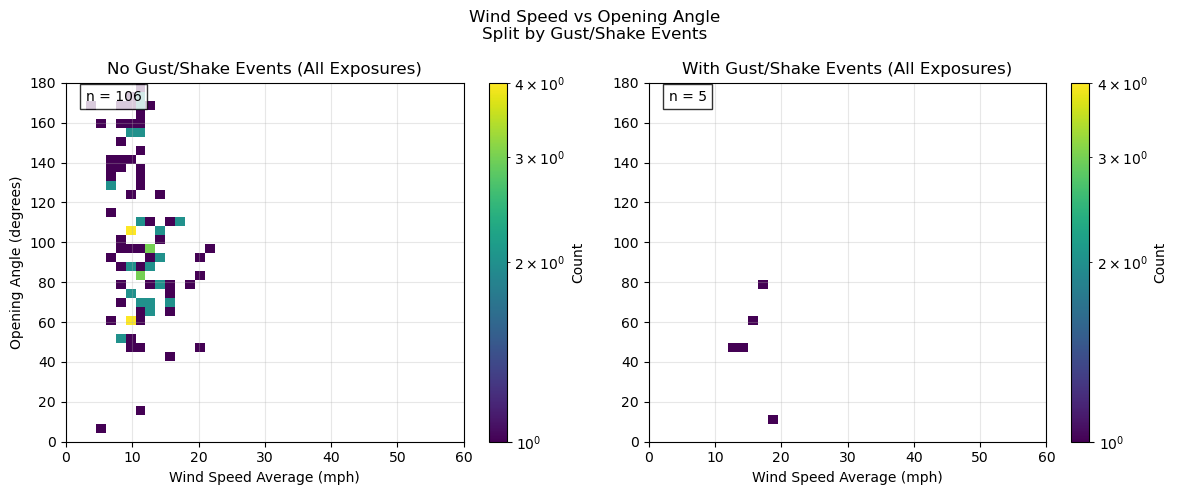

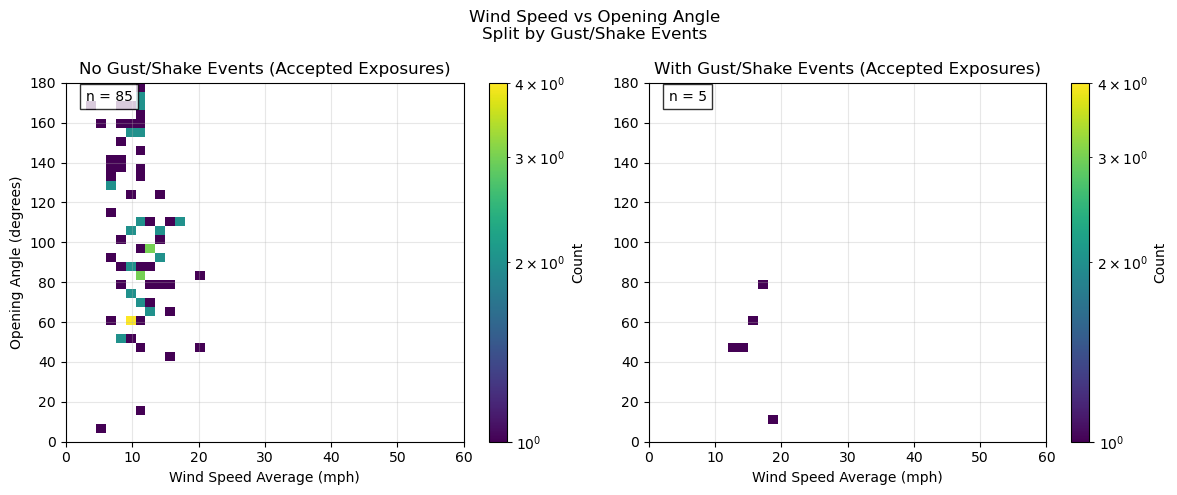

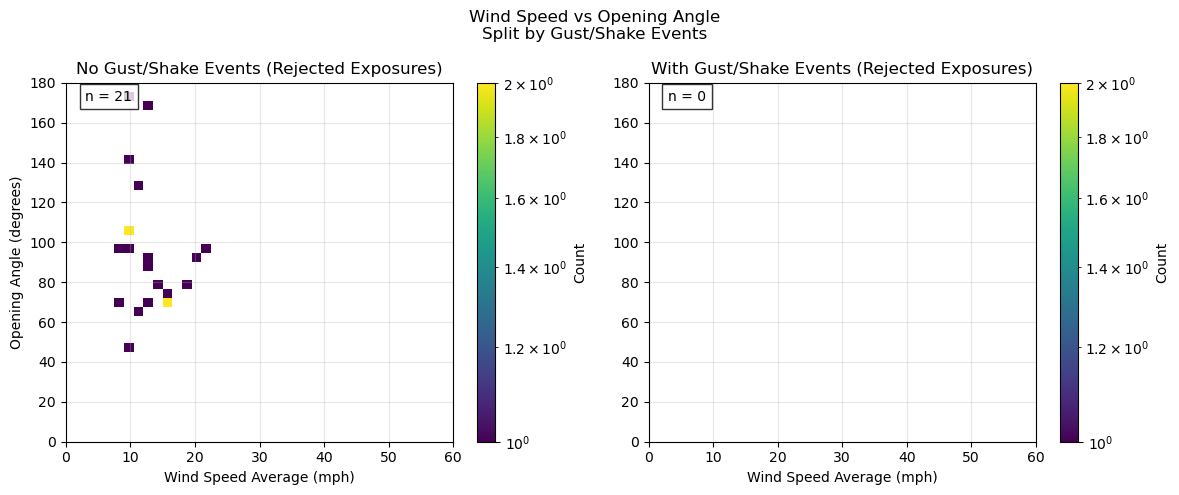

In [19]:
def plot_wind_speed_vs_angle_2dhist(df, accepted=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Wind Speed vs Opening Angle\nSplit by Gust/Shake Events')
    if accepted is True:
        program_mask = (df['SEQUENCE'] == 'DESI') & gooddesi
        posttitle = 'Accepted Exposures'
    elif accepted is False:
        program_mask = (df['SEQUENCE'] == 'DESI') & baddesi
        posttitle = 'Rejected Exposures'
    else:
        program_mask = (df['SEQUENCE'] == 'DESI') & desi
        posttitle = 'All Exposures'

    bins = (40, 40)
    range_ = [[0, 60], [0, 180]]
    all_counts = []
    for has_events in [False, True]:
        event_mask = ((df['GUSTS'] + df['SHAKES']) > 0) if has_events else ((df['GUSTS'] + df['SHAKES']) == 0)
        combined_mask = program_mask & event_mask
        filtered = df[['AVGSPEED', 'AVGOPENING']][combined_mask].dropna()
        counts, _, _ = np.histogram2d(filtered['AVGSPEED'], filtered['AVGOPENING'], bins=bins, range=range_)
        all_counts.append(counts)

    positive = [c[c > 0] for c in all_counts if (c > 0).any()]
    if positive:
        vmin = min(c.min() for c in positive)
        vmax = max(c.max() for c in all_counts)
        norm = plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None

    for i, has_events in enumerate([False, True]):
        ax = axes[i]
        event_mask = ((df['GUSTS'] + df['SHAKES']) > 0) if has_events else ((df['GUSTS'] + df['SHAKES']) == 0)
        title_prefix = 'With' if has_events else 'No'
        combined_mask = program_mask & event_mask
        filtered = df[['AVGSPEED', 'AVGOPENING']][combined_mask].dropna()

        hist = ax.hist2d(filtered['AVGSPEED'], filtered['AVGOPENING'], bins=bins, range=range_,
                          cmap='viridis', norm=norm)
        plt.colorbar(hist[3], ax=ax, label='Count')
        ax.set_xlabel('Wind Speed Average (mph)')
        if i == 0:
            ax.set_ylabel('Opening Angle (degrees)')
        ax.set_title(f'{title_prefix} Gust/Shake Events ({posttitle})')
        ax.set_ylim(0, 180)
        ax.set_xlim(0, 60)
        ax.grid(True, alpha=0.3)
        ax.text(0.05, 0.95, f'n = {len(filtered)}', transform=ax.transAxes,
                bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    return fig, axes


for accepted in [None, True, False]:
    plot_wind_speed_vs_angle_2dhist(windDF, accepted=accepted)


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: xlabel='Opening Angle (degrees)', ylabel='Number of Exposures'>,
        <Axes: xlabel='Wind Speed Average (mph)'>], dtype=object))

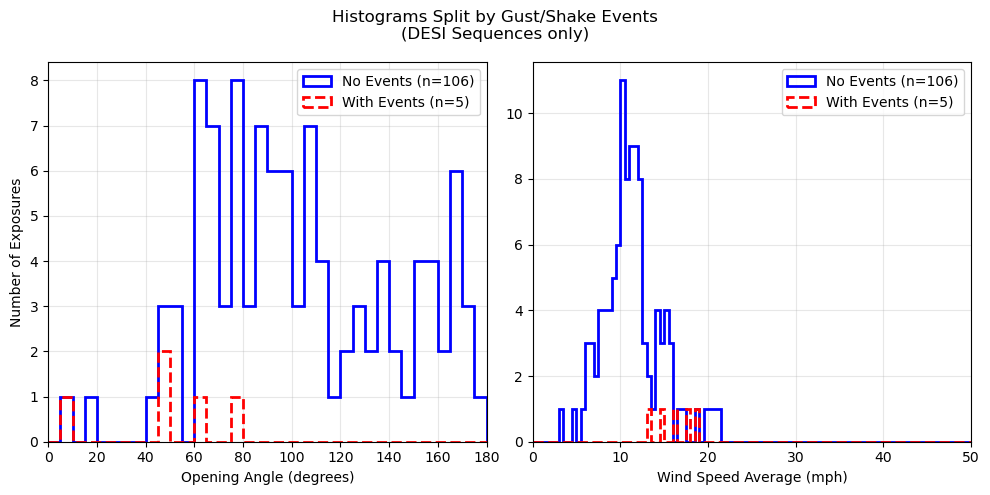

In [20]:
def plot_histogram_distributions(df, accepted=None):
    """Histograms of opening angle and wind speed, split by shake/gust events (DESI sequences only)."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle('Histograms Split by Gust/Shake Events\n(DESI Sequences only)')
    if accepted is True:
        program_mask = (df['SEQUENCE'] == 'DESI') & gooddesi
    elif accepted is False:
        program_mask = (df['SEQUENCE'] == 'DESI') & baddesi
    else:
        program_mask = (df['SEQUENCE'] == 'DESI') & desi

    variables = {
        'AVGOPENING': {'xlabel': 'Opening Angle (degrees)', 'xlim': (0, 180), 'bins': np.linspace(0, 180, 37)},
        'AVGSPEED': {'xlabel': 'Wind Speed Average (mph)', 'xlim': (0, 50), 'bins': np.linspace(0, 50, 101)},
    }
    styles = [
        {'color': 'blue', 'linestyle': '-', 'label': 'No Events'},
        {'color': 'red', 'linestyle': '--', 'label': 'With Events'},
    ]

    for ax_idx, (var_name, properties) in enumerate(variables.items()):
        ax = axes[ax_idx]
        for event_idx, has_events in enumerate([False, True]):
            event_mask = ((df['GUSTS'] + df['SHAKES']) > 0) if has_events else ((df['GUSTS'] + df['SHAKES']) == 0)
            data = df[program_mask & event_mask][var_name].dropna()
            ax.hist(data, bins=properties['bins'], color=styles[event_idx]['color'],
                    linestyle=styles[event_idx]['linestyle'], histtype='step',
                    label=f"{styles[event_idx]['label']} (n={len(data)})", linewidth=2)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(properties['xlabel'])
        ax.set_xlim(properties['xlim'])
        if ax_idx == 0:
            ax.set_ylabel('Number of Exposures')
        ax.legend()

    plt.tight_layout()
    return fig, axes


plot_histogram_distributions(windDF, accepted=None)


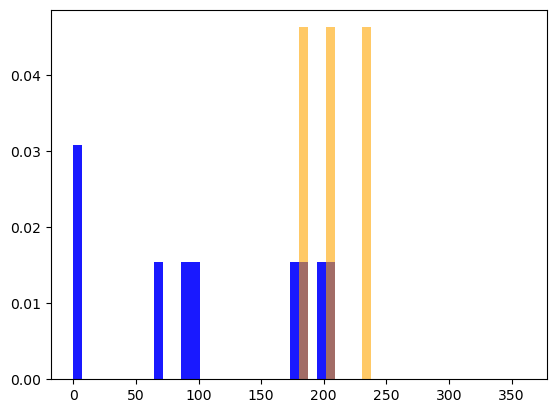

In [21]:
angle = windDF['AVGOPENING'] < 60.0
data = windDF['AZ'][desinowind & angle].astype(float)
plt.hist(data, color='blue', alpha=0.9, range=(0, 360), bins=50, density=True)
data = windDF['AZ'][desiwind & angle].astype(float)
plt.hist(data, color='orange', alpha=0.6, range=(0, 360), bins=50, density=True)
plt.show()
